Używany plik: heart_attack_prediction_dataset.csv
Kształt zbioru: (8763, 26)

========== Trenowanie: Logistic Regression ==========
Accuracy: 0.5037
Precision: 0.3590
Recall: 0.4904
F1-score: 0.4145
ROC-AUC: 0.5057

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.51      0.57      1125
           1       0.36      0.49      0.41       628

    accuracy                           0.50      1753
   macro avg       0.50      0.50      0.49      1753
weighted avg       0.54      0.50      0.51      1753



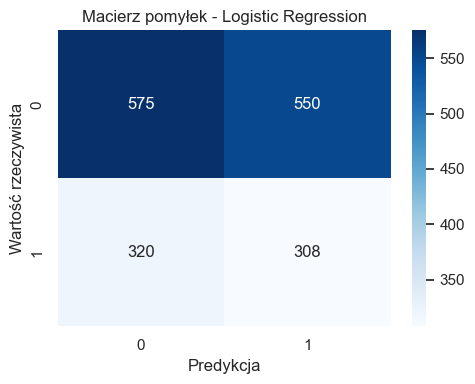

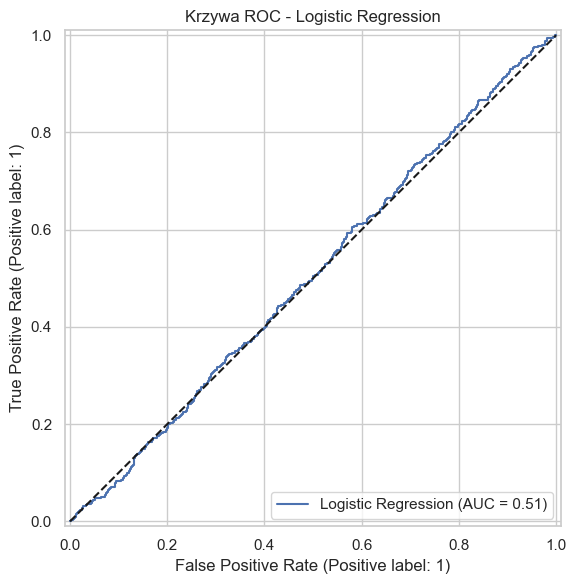

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_CANDIDATES = [
    "heart_attack_prediction_dataset.csv",
    "heart_attack_prediction_dataset (1).csv",
    "Heart Attack Risk Prediction Dataset.csv",
    "heart.csv",
    "data.csv",
]

def find_data_file():
    for name in DATA_CANDIDATES:
        if Path(name).exists(): return Path(name)
    csvs = list(Path(".").glob("*.csv"))
    if csvs: return csvs[0]
    raise FileNotFoundError("Nie znaleziono pliku CSV w bieżącym katalogu.")

def load_and_prepare_data(path: Path):
    df = pd.read_csv(path)
    print(f"Używany plik: {path}\nKształt zbioru: {df.shape}")

    if "Blood Pressure" in df.columns:
        bp = df["Blood Pressure"].astype(str).str.split("/", expand=True)
        df["BP_sys"] = pd.to_numeric(bp[0], errors="coerce")
        df["BP_dia"] = pd.to_numeric(bp[1], errors="coerce")
        df.drop(columns=["Blood Pressure"], inplace=True)

    if "Patient ID" in df.columns:
        df.drop(columns=["Patient ID"], inplace=True)

    target_col = "Heart Attack Risk"
    X = df.drop(columns=[target_col])
    y = df[target_col]

    categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
    numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()
    return X, y, numerical_features, categorical_features, df

def plot_basic_eda(df):
    plt.figure(figsize=(6, 4))
    sns.countplot(x="Heart Attack Risk", data=df)
    plt.title("Rozkład klas - Heart Attack Risk")
    plt.tight_layout()
    plt.savefig("target_distribution.png", dpi=200)
    plt.close()

    if "Age" in df.columns:
        plt.figure(figsize=(6, 4))
        sns.histplot(df["Age"], kde=True, bins=30)
        plt.title("Histogram - Wiek pacjentów")
        plt.tight_layout()
        plt.savefig("hist_age.png", dpi=200)
        plt.close()


data_path = find_data_file()
X, y, num_features, cat_features, df = load_and_prepare_data(data_path)
plot_basic_eda(df)


numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_features),
    ("cat", cat_transformer, cat_features)
])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42,
        class_weight="balanced",
        C=0.1
    ))
])

print("\n========== Trenowanie: Logistic Regression ==========")
logistic_model.fit(X_train, y_train)


y_pred = logistic_model.predict(X_test)
y_proba = logistic_model.predict_proba(X_test)[:, 1]


print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Macierz pomyłek - Logistic Regression")
plt.xlabel("Predykcja")
plt.ylabel("Wartość rzeczywista")
plt.tight_layout()
plt.savefig("confusion_matrix_logistic_regression.png", dpi=200)
plt.show()


RocCurveDisplay.from_estimator(logistic_model, X_test, y_test, name="Logistic Regression")
plt.plot([0, 1], [0, 1], "k--")
plt.title("Krzywa ROC - Logistic Regression")
plt.tight_layout()
plt.savefig("roc_logistic_regression.png", dpi=200)
plt.show()


with open("results_logistic.txt", "w") as f:
    f.write(f"LR_Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
    f.write(f"LR_Recall: {recall_score(y_test, y_pred):.4f}\n")
    f.write(f"LR_F1: {f1_score(y_test, y_pred):.4f}\n")
    f.write(f"LR_AUC: {roc_auc_score(y_test, y_proba):.4f}\n")


In [2]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_CANDIDATES = [
    "heart_attack_prediction_dataset.csv",
    "heart_attack_prediction_dataset (1).csv",
    "Heart Attack Risk Prediction Dataset.csv",
    "heart.csv",
    "data.csv",
]

def find_data_file():
    for name in DATA_CANDIDATES:
        if Path(name).exists(): return Path(name)
    csvs = list(Path(".").glob("*.csv"))
    if csvs: return csvs[0]
    raise FileNotFoundError("Nie znaleziono pliku CSV w bieżącym katalogu.")

def load_and_prepare_data(path: Path):
    df = pd.read_csv(path)
    
    if "Blood Pressure" in df.columns:
        bp = df["Blood Pressure"].astype(str).str.split("/", expand=True)
        df["BP_sys"] = pd.to_numeric(bp[0], errors="coerce")
        df["BP_dia"] = pd.to_numeric(bp[1], errors="coerce")
        df.drop(columns=["Blood Pressure"], inplace=True)

    if "Patient ID" in df.columns:
        df.drop(columns=["Patient ID"], inplace=True)

    target_col = "Heart Attack Risk"
    X = df.drop(columns=[target_col])
    y = df[target_col]

    categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
    numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()
    return X, y, numerical_features, categorical_features

def main():
    data_path = find_data_file()
    X, y, num_features, cat_features = load_and_prepare_data(data_path)

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    cat_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, num_features),
        ("cat", cat_transformer, cat_features)
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print("\n========== KROK 1: Bazowy Random Forest ==========")
    rf_base = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"))
    ])
    rf_base.fit(X_train, y_train)
    y_pred_base = rf_base.predict(X_test)
    print(f"Bazowy ROC-AUC: {roc_auc_score(y_test, rf_base.predict_proba(X_test)[:, 1]):.4f}")

    print("\n========== KROK 2: Strojenie hiperparametrów (GridSearchCV) ==========")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    rf_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42, class_weight="balanced"))
    ])

    param_grid = {
        "classifier__n_estimators": [100, 200],
        "classifier__max_depth": [5, 10, None],
        "classifier__min_samples_split": [2, 5],
        "classifier__min_samples_leaf": [1, 4]
    }

    grid_search = GridSearchCV(
        estimator=rf_pipeline, param_grid=param_grid, scoring="roc_auc", cv=cv, n_jobs=-1, verbose=1
    )
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    y_pred_best = best_model.predict(X_test)
    y_proba_best = best_model.predict_proba(X_test)[:, 1]

    print("\nNajlepsze parametry zoptymalizowanego modelu:")
    print(grid_search.best_params_)

    print("\nWyniki końcowe (Random Forest Tuned):")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_best, zero_division=0):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred_best, zero_division=0):.4f}")
    print(f"F1-score: {f1_score(y_test, y_pred_best, zero_division=0):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_best):.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred_best, zero_division=0))

    # Wykres Macierzy Pomyłek
    cm = confusion_matrix(y_test, y_pred_best)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
    plt.title("Macierz pomyłek - Random Forest (Tuned)")
    plt.xlabel("Predykcja")
    plt.ylabel("Wartość rzeczywista")
    plt.tight_layout()
    plt.savefig("confusion_matrix_rf_tuned.png", dpi=200)
    plt.close()

    # Wykres ROC
    plt.figure(figsize=(6, 4))
    RocCurveDisplay.from_estimator(best_model, X_test, y_test, name="Random Forest (Tuned)")
    plt.plot([0, 1], [0, 1], "k--")
    plt.title("ROC - Random Forest (Tuned)")
    plt.tight_layout()
    plt.savefig("roc_rf_tuned.png", dpi=200)
    plt.close()

    # Ekstrakcja ważności cech
    fitted_preprocessor = best_model.named_steps["preprocessor"]
    fitted_classifier = best_model.named_steps["classifier"]
    feature_names = fitted_preprocessor.get_feature_names_out()
    importances = fitted_classifier.feature_importances_

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values(by="importance", ascending=False).head(15)

    # Wykres istotności cech
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis")
    plt.title("Top 15 najważniejszych cech - Random Forest")
    plt.xlabel("Ważność")
    plt.ylabel("Cecha")
    plt.tight_layout()
    plt.savefig("feature_importance_rf.png", dpi=200)
    plt.close()

    # Eksport modelu i zestawień
    importance_df.to_csv("feature_importance_top15.csv", index=False)
    joblib.dump(best_model, "best_random_forest_model.pkl")
    
    with open("results_rf.txt", "w") as f:
        f.write(f"RF_Accuracy: {accuracy_score(y_test, y_pred_best):.4f}\n")
        f.write(f"RF_Recall: {recall_score(y_test, y_pred_best):.4f}\n")
        f.write(f"RF_F1: {f1_score(y_test, y_pred_best):.4f}\n")
        f.write(f"RF_AUC: {roc_auc_score(y_test, y_proba_best):.4f}\n")

    print("\n[Zrobione] Skrypt Random Forest i optymalizacja zakończone. Wyniki zapisane.")

if __name__ == "__main__":
    main()


========== KROK 1: Bazowy Random Forest ==========
Bazowy ROC-AUC: 0.5134

========== KROK 2: Strojenie hiperparametrów (GridSearchCV) ==========
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Najlepsze parametry zoptymalizowanego modelu:
{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Wyniki końcowe (Random Forest Tuned):
Accuracy: 0.5328
Precision: 0.3704
Recall: 0.4347
F1-score: 0.4000
ROC-AUC: 0.5120

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.59      0.62      1125
           1       0.37      0.43      0.40       628

    accuracy                           0.53      1753
   macro avg       0.51      0.51      0.51      1753
weighted avg       0.55      0.53      0.54      1753


[Zrobione] Skrypt Random Forest i optymalizacja zakończone. Wyniki zapisane.


<Figure size 600x400 with 0 Axes>